In [1]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2025-11-06 16:14:24--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.007s  

2025-11-06 16:14:25 (127 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

import xgboost as xgb

In [2]:
# 1. Load the data
df = pd.read_csv('car_fuel_efficiency.csv')

# 2. Fill missing values with zeros
df = df.fillna(0)

# 3. Split the data (60/20/20) with random_state=1
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

# 4. Separate the target variable (y)
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# 5. Remove target from the feature dataframes
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# 6. Use DictVectorizer(sparse=True)
# Convert dataframes to lists of dictionaries
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')

# Initialize and fit the vectorizer
# sparse=True is more memory-efficient
dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(train_dicts)

# Transform the validation data
X_val = dv.transform(val_dicts)

print(f"Data prepared and vectorized.")
print(f"X_train is a sparse matrix with shape: {X_train.shape}")

Data prepared and vectorized.
X_train is a sparse matrix with shape: (5822, 14)


In [3]:
# 1. Initialize the Decision Tree Regressor
# We set max_depth=1 as requested
dt = DecisionTreeRegressor(max_depth=1)

# 2. Train the model on our training data
dt.fit(X_train, y_train)

# 3. Use export_text to see the rule
# We get the feature names from our DictVectorizer
feature_names = list(dv.get_feature_names_out())
tree_rules = export_text(dt, feature_names=feature_names)

print("--- Decision Tree (max_depth=1) ---")
print(tree_rules)

--- Decision Tree (max_depth=1) ---
|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



In [4]:
# 1. Initialize the Random Forest Regressor
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)

# 2. Train the model
rf.fit(X_train, y_train)

# 3. Get predictions on the validation set
y_pred = rf.predict(X_val)

# 4. Calculate the RMSE
# mean_squared_error calculates (y_pred - y_val)^2
# np.sqrt takes the square root of the average
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

print(f"The RMSE of the model on the validation data is: {rmse:.3f}")

The RMSE of the model on the validation data is: 0.460


--- Running n_estimators experiment ---
(10, np.float64(0.4595777223092726))
(20, np.float64(0.45359067251247054))
(30, np.float64(0.45168672575457125))
(40, np.float64(0.4487208301736996))
(50, np.float64(0.4466568972416094))
(60, np.float64(0.44545970260811213))
(70, np.float64(0.4451263244986996))
(80, np.float64(0.4449843119777284))
(90, np.float64(0.4448614906399875))
(100, np.float64(0.4446518680868042))
(110, np.float64(0.44357876439860233))
(120, np.float64(0.4439118681233817))
(130, np.float64(0.443702590396687))
(140, np.float64(0.4433549955101688))
(150, np.float64(0.44289761494219454))
(160, np.float64(0.4427612219659299))
(170, np.float64(0.44280146504730905))
(180, np.float64(0.44236195357041347))
(190, np.float64(0.4424939711220692))
(200, np.float64(0.4424785084688597))


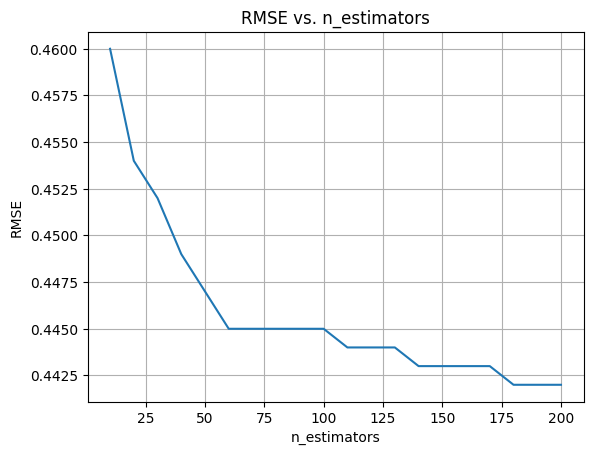

    n_estimators      rmse
0             10  0.459578
1             20  0.453591
2             30  0.451687
3             40  0.448721
4             50  0.446657
5             60  0.445460
6             70  0.445126
7             80  0.444984
8             90  0.444861
9            100  0.444652
10           110  0.443579
11           120  0.443912
12           130  0.443703
13           140  0.443355
14           150  0.442898
15           160  0.442761
16           170  0.442801
17           180  0.442362
18           190  0.442494
19           200  0.442479


In [5]:
# A list to store the RMSE scores
scores = []

# Create a range of estimators to try, from 10 to 200
estimators = range(10, 201, 10)

print("--- Running n_estimators experiment ---")

# Loop through each estimator value
for n in estimators:
    # Initialize the model with this 'n'
    rf = RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1)
    
    # Train the model
    rf.fit(X_train, y_train)
    
    # Get predictions
    y_pred = rf.predict(X_val)
    
    # Calculate RMSE and add to our list
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    scores.append((n, rmse))
    print(scores[-1])

# --- Plot the results ---
# Get the n's and rmse's from our list
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

plt.plot(df_scores.n_estimators, df_scores.rmse.round(3))
plt.title('RMSE vs. n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

# Print the scores to inspect them
print(df_scores)

In [6]:
# The parameters to test
max_depths = [10, 15, 20, 25]
estimators = range(10, 201, 10)

print("--- Running max_depth experiment ---")

# Outer loop: iterate over max_depth values
for depth in max_depths:
    
    depth_scores = [] # A list to store scores for *this* depth
    
    # Inner loop: iterate over n_estimators
    for n in estimators:
        # Initialize the model with this depth and n
        rf = RandomForestRegressor(n_estimators=n, 
                                max_depth=depth, 
                                random_state=1, 
                                n_jobs=-1)
        
        # Train the model
        rf.fit(X_train, y_train)
        
        # Get predictions
        y_pred = rf.predict(X_val)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        depth_scores.append(rmse)

    # After the inner loop, calculate the mean RMSE for this depth
    mean_rmse = np.mean(depth_scores)
    print(f"max_depth = {depth:2}: Mean RMSE = {mean_rmse:.3f}")

--- Running max_depth experiment ---
max_depth = 10: Mean RMSE = 0.442
max_depth = 15: Mean RMSE = 0.445
max_depth = 20: Mean RMSE = 0.446
max_depth = 25: Mean RMSE = 0.446


In [8]:
# 1. Initialize the model with Q5 parameters
rf_q5 = RandomForestRegressor(n_estimators=10, 
                            max_depth=20, 
                            random_state=1, 
                            n_jobs=-1)

# 2. Train the model
rf_q5.fit(X_train, y_train)

# 3. Get feature importances
importances = rf_q5.feature_importances_

# 4. Get feature names
features = list(dv.get_feature_names_out())

# 5. Create a DataFrame to view them
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importances})

# Sort by importance (highest first) and print
print("--- Most Important Features ---")
print(feature_importance_df.sort_values(by='importance', ascending=False))

--- Most Important Features ---
                         feature  importance
13                vehicle_weight    0.959150
6                     horsepower    0.015998
0                   acceleration    0.011480
3            engine_displacement    0.003273
7                     model_year    0.003212
8                  num_cylinders    0.002343
9                      num_doors    0.001635
12                    origin=USA    0.000540
11                 origin=Europe    0.000519
10                   origin=Asia    0.000462
5             fuel_type=Gasoline    0.000360
1     drivetrain=All-wheel drive    0.000357
2   drivetrain=Front-wheel drive    0.000345
4               fuel_type=Diesel    0.000325


In [9]:
# 1. Get feature names from our vectorizer
#    XGBoost needs this for its DMatrix
features = list(dv.get_feature_names_out())

# 2. Create the DMatrix for train and validation
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

# 3. Create a watchlist
watchlist = [(dtrain, 'train'), (dval, 'validation')]

# 4. A dictionary to store the results
scores = {}

# --- Experiment 1: eta = 0.3 ---
print("--- Training with eta=0.3 ---")
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

# We'll save the evaluation results in this dict
evals_result_1 = {} 
model_1 = xgb.train(xgb_params, 
                    dtrain, 
                    num_boost_round=100,
                    evals=watchlist,
                    evals_result=evals_result_1,
                    verbose_eval=False) # We'll silence the per-round output

# Get the *final* RMSE from the validation set
final_rmse_1 = evals_result_1['validation']['rmse'][-1]
print(f"Final RMSE with eta=0.3: {final_rmse_1:.3f}")


# --- Experiment 2: eta = 0.1 ---
print("\n--- Training with eta=0.1 ---")
# Update the eta in our params
xgb_params['eta'] = 0.1 

evals_result_2 = {}
model_2 = xgb.train(xgb_params, 
                    dtrain, 
                    num_boost_round=100,
                    evals=watchlist,
                    evals_result=evals_result_2,
                    verbose_eval=False)

final_rmse_2 = evals_result_2['validation']['rmse'][-1]
print(f"Final RMSE with eta=0.1: {final_rmse_2:.3f}")

--- Training with eta=0.3 ---
Final RMSE with eta=0.3: 0.450

--- Training with eta=0.1 ---
Final RMSE with eta=0.1: 0.426
